In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import gdown

plt.rc('font', family='NanumBarunGothic')
plt.rc('figure', dpi=100)

gdown.download(r'https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

Downloading...
From: https://bit.ly/3pK7iuu
To: c:\data\ns_book7.csv
100%|██████████| 53.8M/53.8M [00:04<00:00, 12.0MB/s]


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


C:\Users\박중현\AppData\Local\Temp\ipykernel_11740\4059955305.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


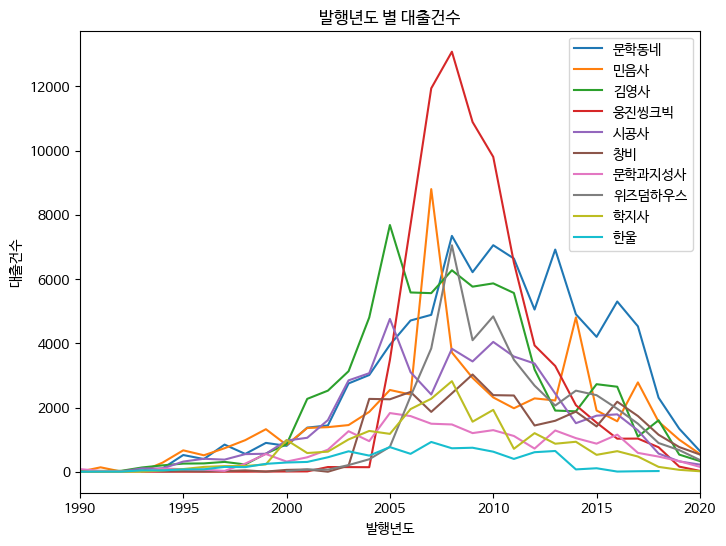

In [86]:
top30_pubs=ns_book7['출판사'].value_counts()[:30]
top30_pubs_idx = ns_book7['출판사'].isin(top30_pubs.index)

ns_book9 = ns_book7[top30_pubs_idx][['출판사', '발행년도', '대출건수']]
ns_book9 = ns_book9.groupby(['출판사','발행년도']).sum()
ns_book9 = ns_book9.reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
for i in top30_pubs[:10].index:
    df = ns_book9[ns_book9['출판사']==i]
    ax.plot(df['발행년도'], df['대출건수'], label=i)
ax.set_title('발행년도 별 대출건수')
ax.set_xlabel('발행년도')
ax.set_xlim(1990, 2020)
ax.set_xticks(range(1990, 2021, 5))
ax.set_ylabel('대출건수')
ax.legend()
fig.show()

TypeError: 'value' must be an instance of str or bytes, not a tuple

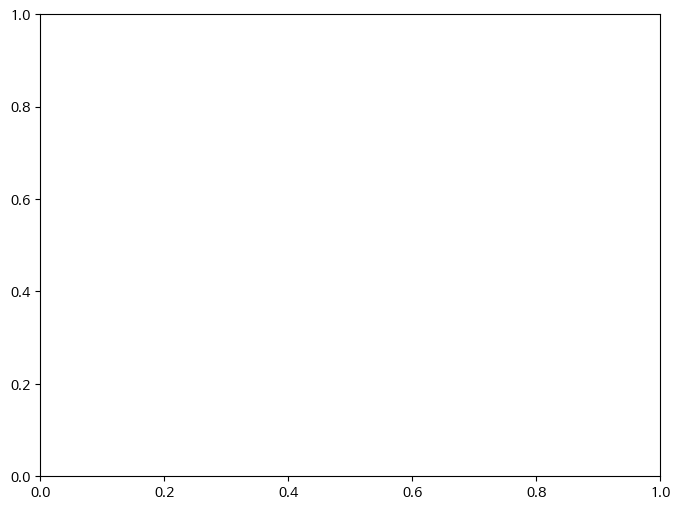

In [87]:
ns_book10 = ns_book9.pivot_table(index='출판사', columns='발행년도')
ns_book10.loc[top30_pubs.index[:10]].fillna(0) #stack plots는 y축 값들을 층층히 쌓은형태, 2차원의 배열 형태로 전달. -> y
ns_book10.columns.get_level_values(0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.stackplot(ns_book10.columns, ns_book10.loc[top30_pubs.index[:10]].fillna(0), labels=top30_pubs.index[:10])
ax.set_title('발행년도 별 대출건수')
ax.legend(loc='upper left')
ax.set_xlim(1985, 2025)
fig.show()

C:\Users\박중현\AppData\Local\Temp\ipykernel_4732\3898932238.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


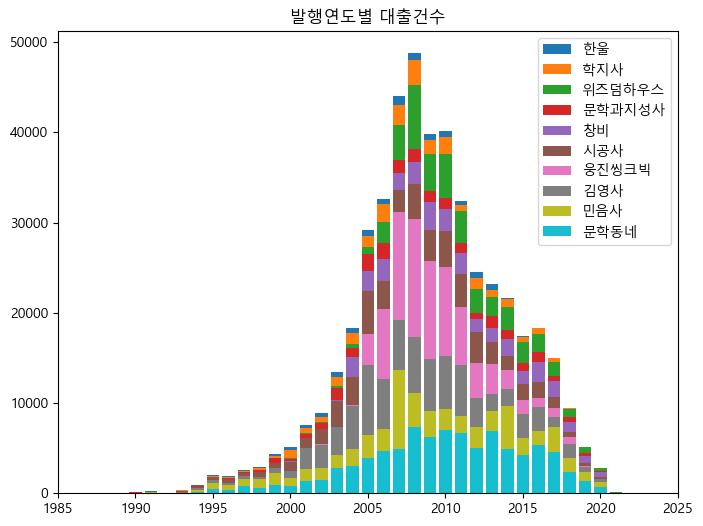

In [ ]:
# #여러 개의 막대 그래프 겹쳐그리기
n = ns_book7['출판사'].value_counts()[:30]
ns_book9 = ns_book7[ns_book7['출판사'].isin(n.index)]
df = ns_book9.groupby(by=['출판사', '발행년도'])['대출건수'].sum()
df = df.reset_index()
line1 = df[df['출판사']=='황금가지']
line2 = df[df['출판사']=='비룡소']

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(line1['발행년도']-0.5, line1['대출건수'], width=1, label='황금가지')
ax.bar(line2['발행년도']+0.5, line2['대출건수'], width=1, label='비룡소')
ax.set_title('발행년도 별 대출건수')
ax.legend(loc='upper right')
fig.show()

#스택 막대 그래프(위로 겹치기)
ns_book10.loc[top10_pubs[:5], ('대출건수', 2013):('대출건수', 2020)].cumsum() #판다스 누적합계 메서드 cumsum
ns_book12 = ns_book10.loc[top10_pubs].fillna(0).cumsum(axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
for i in reversed(range(len(ns_book12.index))): #누적 막대그래프는 가장 큰 값(마지막 값)을 먼저 그래프로 만들어서 큰 값이 작은 값을 덮어쓰지 않도록.
    y = ns_book12.iloc[i]
    label = ns_book12.index[i]
    plt.bar(ns_book12.columns.get_level_values(1), y, label=label)
ax.set_title('발행연도별 대출건수')
ax.legend(loc='upper right')
ax.set_xlim(1985, 2025)
fig.show()

C:\Users\박중현\AppData\Local\Temp\ipykernel_4732\39266337.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


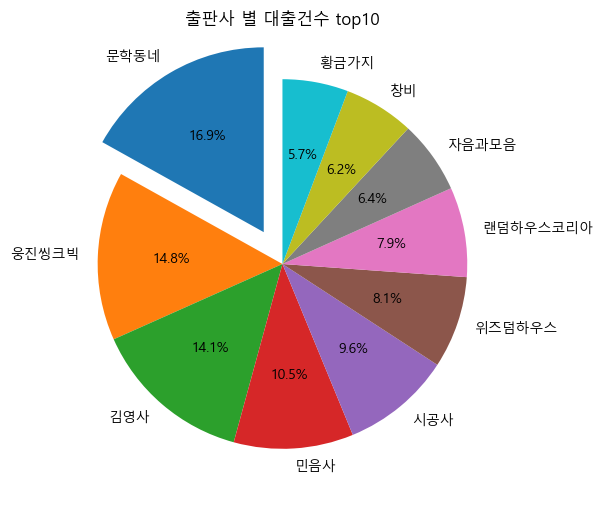

In [ ]:
#원그래프 그리기 pie 메서드 -> 데이터 전달시 자동으로 비율 계산

#출판사별 대출건수 데이터 전달
d = ns_book7.groupby('출판사', dropna=False)['대출건수'].sum().sort_values(ascending=False)[:10]

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.pie(d, labels=d.index, startangle=90)
# ax.set_title('출판사 별 평균 대출건수 top10')
# fig.show()

#비율 표시 & 강조
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(d, labels=d.index, autopct='%.1f%%', explode=[0.2]+[0]*9, startangle=90)
ax.set_title('출판사 별 대출건수 top10')
fig.show()

C:\Users\박중현\AppData\Local\Temp\ipykernel_4732\3073010244.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


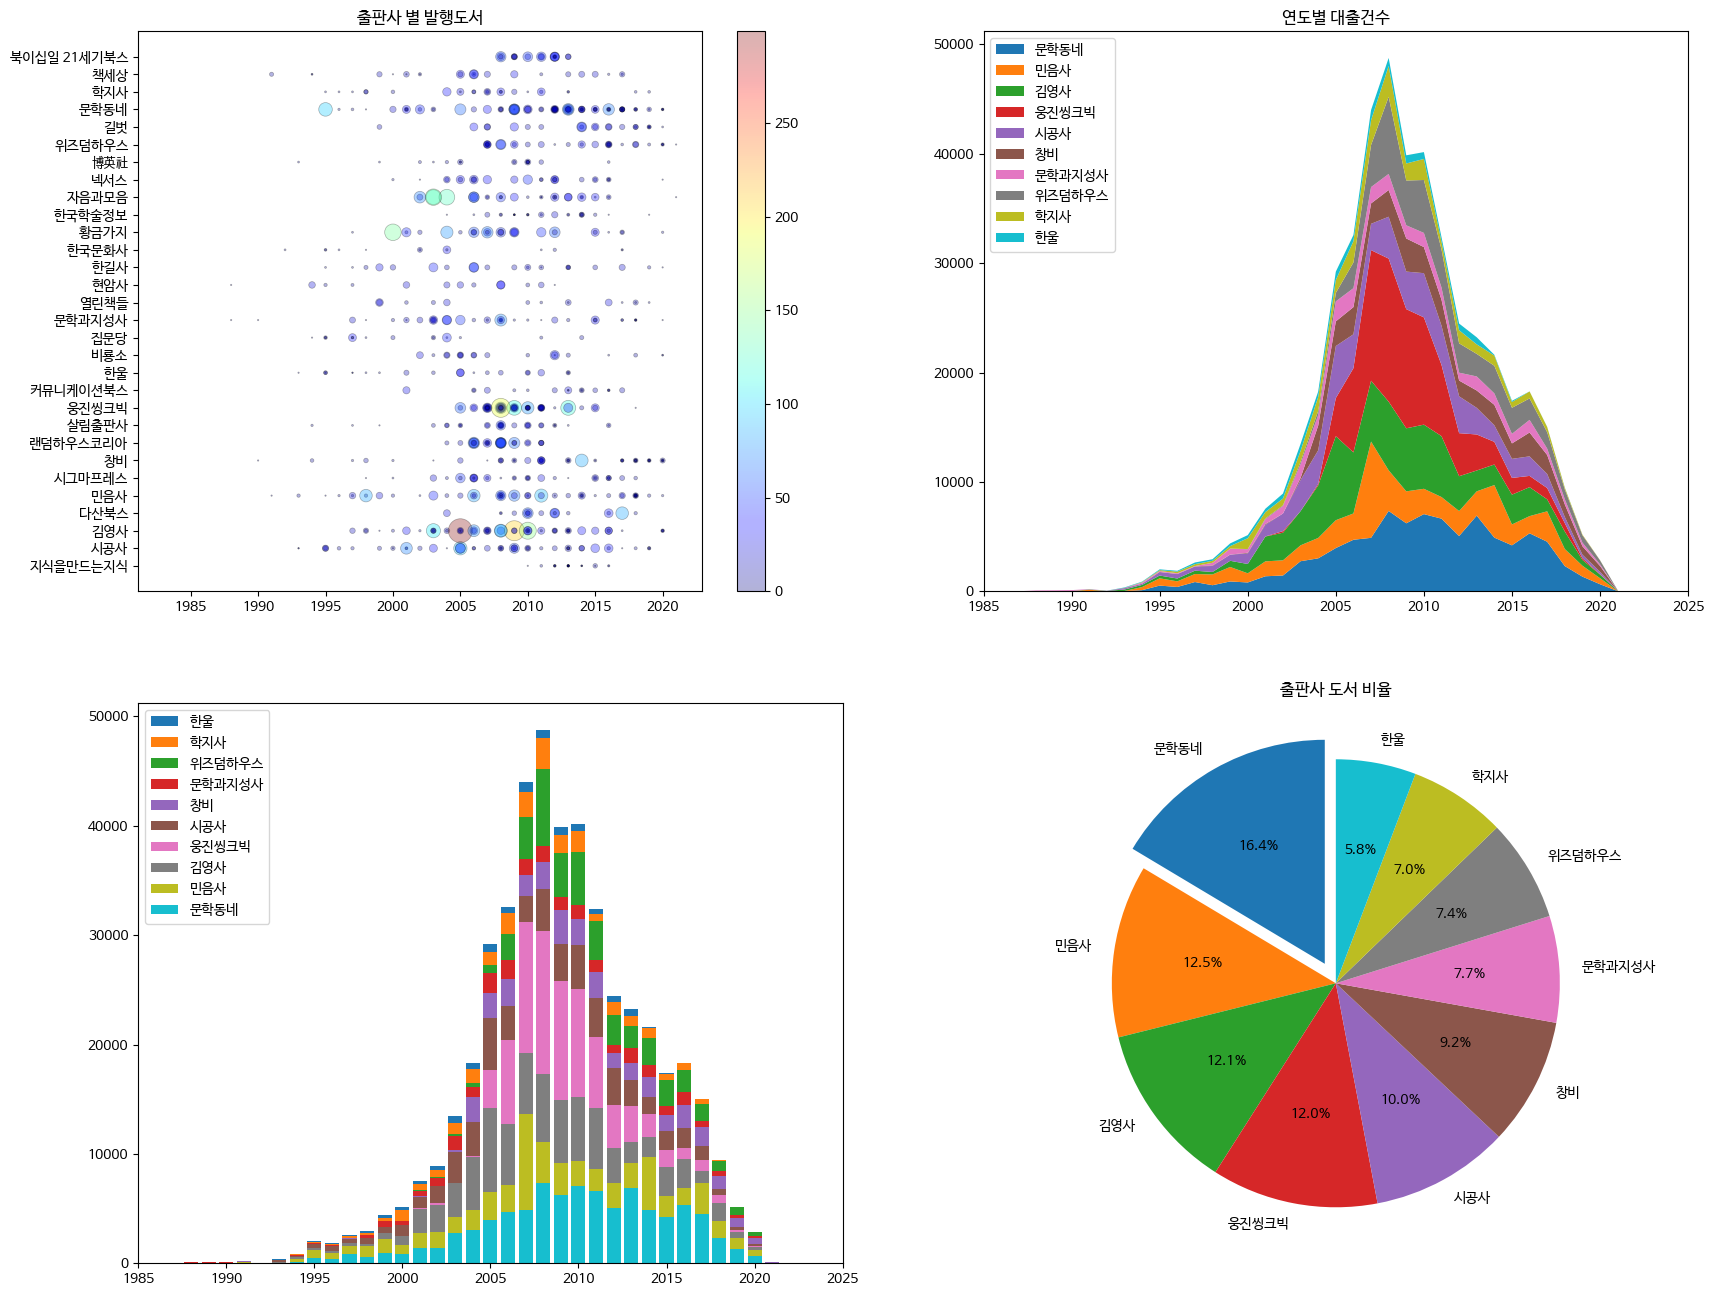

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(20, 16))

plt.rc('font', family='NanumBarunGothic')
#출판사별/연도별 발행도서 top30 및 대출건수 산점도
top30출판사 = ns_book7['출판사'].value_counts()[:30]
df1 = ns_book7[ns_book7['출판사'].isin(top30출판사.index)].sample(1000, random_state=42)
sc = (axs[0, 0].scatter(df1['발행년도'], df1['출판사'],
                        s=df1['대출건수'], c=df1['대출건수'], 
                        linewidths=0.5, edgecolors='black', 
                        cmap='jet', 
                        alpha=0.3))
axs[0, 0].set_title('출판사 별 발행도서')
fig.colorbar(sc, ax=axs[0, 0])

#top10 출판사 별 연도별 대출건수 스택플롯
top10출판사 = top30출판사[:10]
df2 = ns_book7[ns_book7['출판사'].isin(top10출판사.index)]
df2 = df2.groupby(by=['출판사', '발행년도'], dropna=False)['대출건수'].sum().reset_index(name='대출건수')
df2피벗 = df2.pivot_table(index='출판사', columns = '발행년도').fillna(0)
df2피벗 = df2피벗.reindex(top10출판사.index)

axs[0, 1].stackplot(df2피벗.columns.get_level_values(1), df2피벗, labels = top10출판사.index)
axs[0, 1].set_title('연도별 대출건수')
axs[0, 1].set_xlim(1985, 2025)
axs[0, 1].legend(loc = 'upper left')

#top 10 출판사 별 연도별 대출건수 스택 바
df3 = df2피벗.cumsum(axis=0)
reversed(df3.index)

for pub in reversed(df3.index):
    axs[1, 0].bar(df3.columns.get_level_values(1), df3.loc[pub], label=pub)
axs[1, 0].legend(loc = 'upper left')
axs[1, 0].set_xlim(1985, 2025)

#출판사 별 도서 비율 원그래프
df4 = ns_book7['출판사'].value_counts()[:10]
axs[1, 1].pie(df4, startangle=90, autopct='%1.1f%%', explode=[0.1]+[0]*(len(df4)-1), labels=df4.index)
axs[1, 1].set_title('출판사 도서 비율')

fig.savefig('all_in_one.png')
fig.show()

In [ ]:
top30출판사 = ns_book7['출판사'].value_counts()[:30]
df1 = ns_book7[ns_book7['출판사'].isin(top30출판사.index)].sample(1000, random_state=42)

top10출판사 = top30출판사[:10]
df2 = ns_book7[ns_book7['출판사'].isin(top10출판사.index)]
df2 = df2.groupby(by=['출판사', '발행년도'], dropna=False)['대출건수'].sum().reset_index(name='대출건수')
df2피벗 = df2.pivot_table(index='출판사', columns = '발행년도').fillna(0)
df2피벗.loc[top10출판사.index].cumsum(axis=0)


대출건수                                                ...           \
발행년도   1974 1976 1977 1978 1979 1980  1981 1982 1983 1984  ...     2012   
출판사                                                        ...            
문학동네    0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  ...   5051.0   
민음사     1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  ...   7335.0   
김영사     1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  ...  10521.0   
웅진씽크빅   1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  ...  14455.0   
시공사     1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0  ...  17825.0   
창비      1.0  0.0  0.0  2.0  0.0  0.0   0.0  1.0  0.0  1.0  ...  19265.0   
문학과지성사  1.0  0.0  1.0  2.0  7.0  0.0  20.0  1.0  0.0  9.0  ...  19986.0   
위즈덤하우스  1.0  0.0  1.0  2.0  7.0  0.0  20.0  1.0  0.0  9.0  ...  22668.0   
학지사     1.0  0.0  1.0  2.0  7.0  0.0  20.0  1.0  0.0  9.0  ...  23869.0   
한울      1.0  0.0  1.0  2.0  7.0  0.0  20.0  1.0  0.0  9.0  ...  24477.0   

                                                                             \
발행년도       2013     2014     2015     2016     2017    2018    2019    2020   
출판사                                                                           
문학동네     6919.0   4904.0   4201.0   5301.0   4529.0  2306.0  1340.0   645.0   
민음사      9138.0   9709.0   6108.0   6872.0   7311.0  3865.0  2338.0  1197.0   
김영사     11043.0  11590.0   8834.0   9519.0   8405.0  5467.0  2871.0  1529.0   
웅진씽크빅   14336.0  13662.0  10363.0  10548.0   9437.0  6229.0  3030.0  1555.0   
시공사     16769.0  15174.0  12108.0  12335.0  10724.0  6795.0  3352.0  1776.0   
창비      18356.0  17046.0  13519.0  14515.0  12459.0  7947.0  4120.0  2313.0   
문학과지성사  19641.0  18092.0  14393.0  15670.0  13046.0  8418.0  4450.0  2464.0   
위즈덤하우스  21702.0  20617.0  16777.0  17631.0  14542.0  9312.0  5123.0  2829.0   
학지사     22574.0  21550.0  17303.0  18271.0  15015.0  9463.0  5182.0  2844.0   
한울      23220.0  21622.0  17411.0  18276.0  15030.0  9484.0  5182.0  2844.0   

               
발행년도     2021  
출판사            
문학동네     18.0  
민음사      25.0  
김영사      55.0  
웅진씽크빅    55.0  
시공사      60.0  
창비       72.0  
문학과지성사   77.0  
위즈덤하우스  100.0  
학지사     100.0  
한울      100.0  

[10 rows x 47 columns]

C:\Users\박중현\AppData\Local\Temp\ipykernel_11740\145779320.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


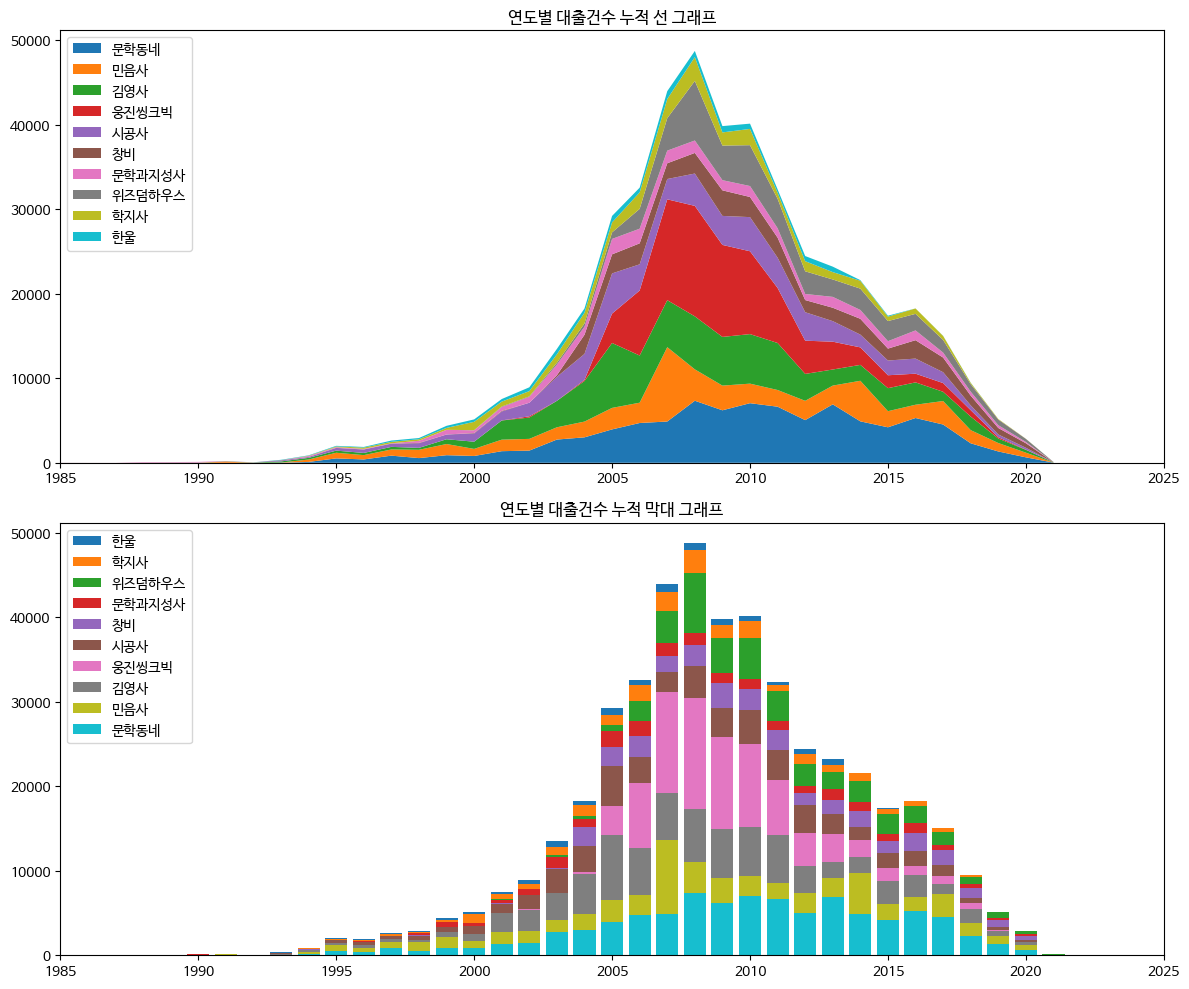

In [120]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_url = r'c:\Windows\Fonts\NanumBarunGothic.ttf'
fm.fontManager.addfont(font_url)
plt.rc('font', family=fm.FontProperties(fname=font_url).get_name())



#연도별 대출건수(출판사) 스택플롯
top10 = ns_book7['출판사'].value_counts()[:10]
top10_idx = top10.index

ns_book8 = ns_book7[ns_book7['출판사'].isin(top10_idx)]
ds = ns_book8.groupby(['출판사', '발행년도'])['대출건수'].sum()
top10_pivot = ds.reset_index().pivot_table(index='출판사', columns = '발행년도', values='대출건수').fillna(0).reindex(top10_idx)

cum_pivot = top10_pivot.cumsum(axis=0)

fig, axs = plt.subplots(2, 1, figsize=(12, 10))
axs[0].stackplot(top10_pivot.columns, top10_pivot, labels=top10_idx)
axs[0].set_title('연도별 대출건수 누적 선 그래프')
axs[0].set_xlim(1985, 2025)
axs[0].legend(loc='upper left')

for i in reversed(range(len(cum_pivot))):
    x = cum_pivot.columns
    label = cum_pivot.index[i]
    y = cum_pivot.iloc[i]
    axs[1].bar(x, y, label=label)
axs[1].set_title('연도별 대출건수 누적 막대 그래프')
axs[1].set_xlim(1985, 2025)
axs[1].legend(loc='upper left')

fig.tight_layout()
fig.show()

C:\Users\박중현\AppData\Local\Temp\ipykernel_11740\78939074.py:3: FutureWarning: The provided callable <function sum at 0x000001CBA66ECA40> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ns_book11 = ns_book7[top30_pubs_idx].pivot_table(index='발행년도', columns='출판사', values = '대출건수', aggfunc=np.sum).fillna(0)
C:\Users\박중현\AppData\Local\Temp\ipykernel_11740\78939074.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\박중현\AppData\Local\Temp\ipykernel_11740\78939074.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


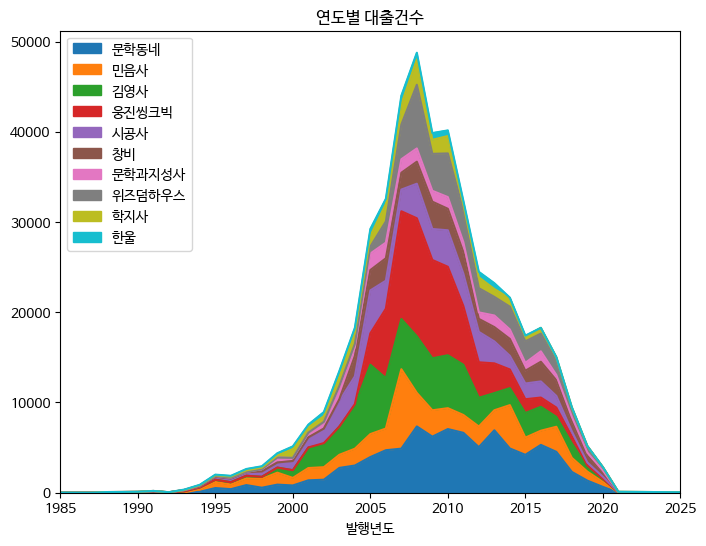

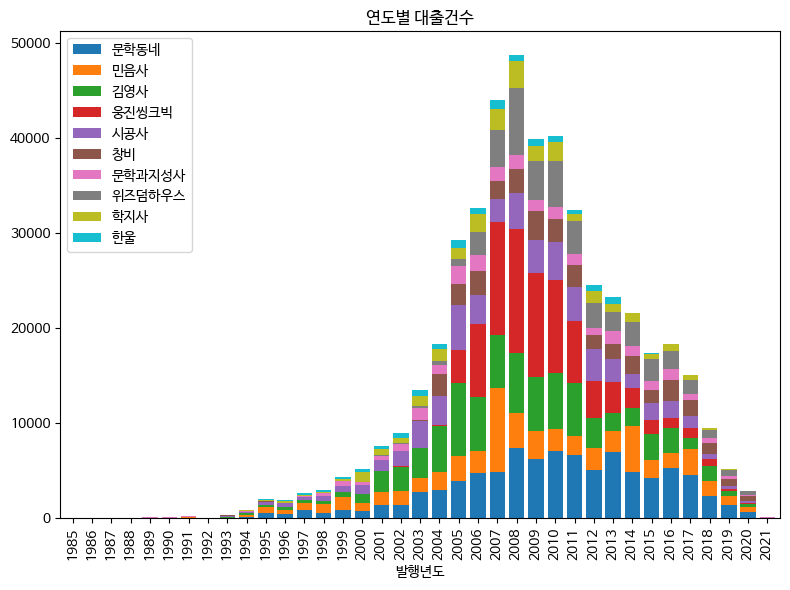

In [ ]:
import numpy as np

ns_book11 = ns_book7[top30_pubs_idx].pivot_table(index='발행년도', columns='출판사', values = '대출건수', aggfunc=np.sum).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
ns_book11[top10_idx].plot.area(ax=ax, title='연도별 대출건수', xlim=(1985, 2025))
ax.legend(loc='upper left')
fig.show()

fig, ax = plt.subplots(figsize=(8, 6))
ns_book11.loc[1985:2025, top10_idx].plot.bar(ax=ax, title='연도별 대출건수', stacked=True, xlim=(1985, 2025), width=0.8)
ax.set_xticks
ax.legend(loc='upper left')
fig.tight_layout()
fig.show()



In [116]:
df = pd.DataFrame({'제품':['에어컨', '선풍기', '냉장고', '전자렌지'], 
             '분류':['냉방', '냉방', '주방', '주방'], 
             '연식':[2022, 2021, 2021, 2021], 
             'A/S횟수':[25, 20, 13, 31]})

df.pivot_table(index='연식', columns='분류', values='A/S횟수', aggfunc=np.sum, fill_value=0)

C:\Users\박중현\AppData\Local\Temp\ipykernel_11740\2756487833.py:6: FutureWarning: The provided callable <function sum at 0x000001CBA66ECA40> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.pivot_table(index='연식', columns='분류', values='A/S횟수', aggfunc=np.sum, fill_value=0)


분류,냉방,주방
연식,,
2021,20,44
2022,25,0
